# 06 — Volatility & Value at Risk

EWMA volatility (RiskMetrics lambda=0.94), 4-method VaR comparison:
Gaussian, Historical, Cornish-Fisher, and Conditional VaR (CVaR/ES).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', '..')))

import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm

from energy_workbook.config import ALL_TICKERS, EQUITY_TICKERS, EWMA_LAMBDA, RF_RATE

VIZ = os.path.abspath(os.path.join('..', 'visualization'))
DATA = os.path.abspath(os.path.join('..', 'data'))

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 11, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC', 'axes.grid': True,
    'grid.alpha': 0.3, 'legend.fontsize': 9,
})
MC_COLORS = ['#002B5C','#1A3C6E','#4A86C8','#0070C0','#C89600',
             '#E06C00','#C00000','#008000','#7030A0','#666666']

EVENT_BANDS = {
    2: ('2020-02-20','2020-06-30','#FFD6D6','COVID'),
    4: ('2022-02-24','2022-12-31','#FFE6CC','Russia-Ukraine'),
    6: ('2025-06-01','2025-06-30','#FFF0CC','12-Day War'),
    7: ('2026-02-28','2026-04-30','#FFD6D6','Iran Conflict'),
}
def add_events(ax):
    for _, (s, e, c, _) in EVENT_BANDS.items():
        try: ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color=c, zorder=0)
        except: pass

def savefig(fig, name, dpi=180):
    fig.savefig(os.path.join(VIZ, name), dpi=dpi, bbox_inches='tight',
                facecolor='white', edgecolor='none')
    print(f'  saved {name}')

cache_path = os.path.abspath(os.path.join('..', '..', 'data_cache.pkl'))
with open(cache_path, 'rb') as f:
    D = pickle.load(f)
MASTER = D['master']; LOG_RET = D['log_returns']
print('Data loaded')

Data loaded


## 6.1 EWMA Volatility

In [2]:
ewma_vols = {}
for t in ALL_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) < 61:
        continue
    var_s = pd.Series(0.0, index=r.index)
    var_s.iloc[:60] = r.iloc[:60].var(ddof=0)
    for i in range(60, len(r)):
        var_s.iloc[i] = EWMA_LAMBDA * var_s.iloc[i-1] + (1 - EWMA_LAMBDA) * r.iloc[i-1]**2
    ewma_vols[t] = np.sqrt(var_s) * np.sqrt(252)

# Current vol ranking
current_vols = {t: float(ewma_vols[t].dropna().iloc[-1]) for t in ALL_TICKERS if t in ewma_vols}
pd.Series(current_vols, name='ewma_vol').to_csv(os.path.join(DATA, 'current_ewma_vol.csv'))

vol_rank = sorted(current_vols.items(), key=lambda x: x[1], reverse=True)
print('Current EWMA Vol Ranking (annualized):')
for t, v in vol_rank:
    print(f'  {t:5s}: {v*100:.1f}%')

Current EWMA Vol Ranking (annualized):
  VG   : 92.8%
  FRO  : 50.5%
  STNG : 46.4%
  LNG  : 40.4%
  OXY  : 39.3%
  XOM  : 32.3%
  COP  : 27.8%
  CVX  : 27.3%
  ET   : 17.1%
  BIL  : 0.3%


  saved 05_ewma_volatility.png


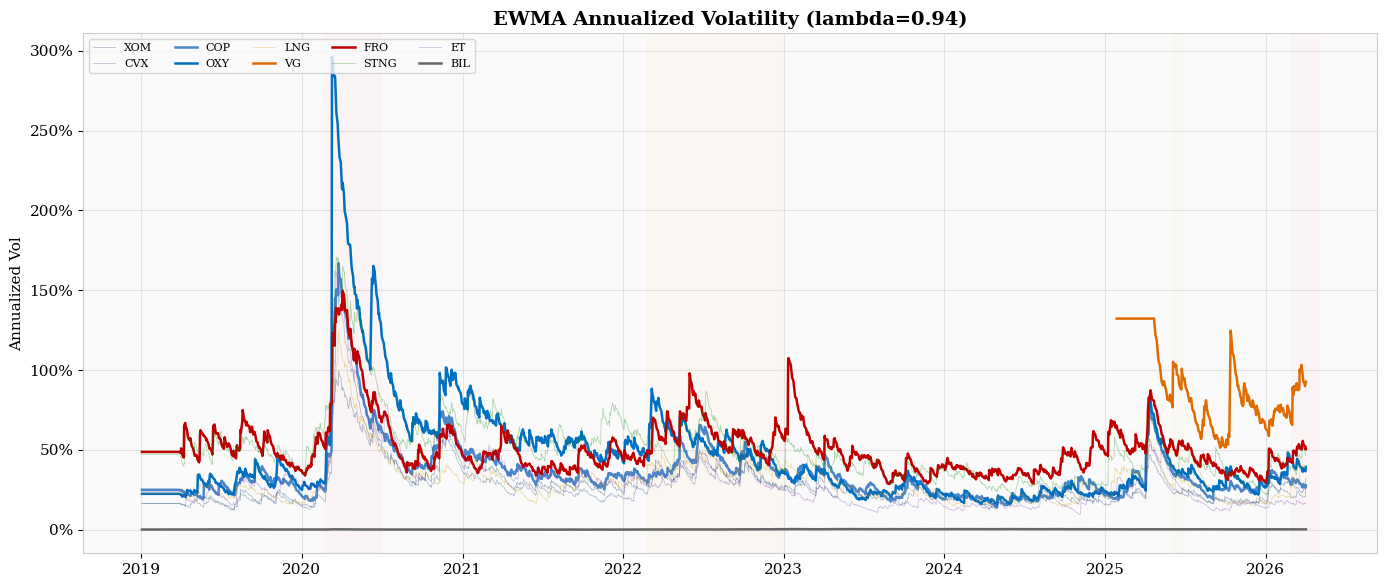

In [3]:
# EWMA Volatility Time Series
highlight = ['COP', 'OXY', 'FRO', 'VG', 'BIL']
fig, ax = plt.subplots(figsize=(14, 6))
for i, t in enumerate(ALL_TICKERS):
    if t in ewma_vols:
        vol = ewma_vols[t]
        ax.plot(vol.index, vol.values, label=t, color=MC_COLORS[i % len(MC_COLORS)],
                linewidth=1.8 if t in highlight else 0.6,
                alpha=1.0 if t in highlight else 0.3)
add_events(ax)
ax.set_title('EWMA Annualized Volatility (lambda=0.94)', fontweight='bold')
ax.set_ylabel('Annualized Vol')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(ncol=5, loc='upper left', fontsize=8)
fig.tight_layout()
savefig(fig, '05_ewma_volatility.png')
plt.show()

In [ ]:
# Current vol ranking bar chart
fig, ax = plt.subplots(figsize=(9, 5))
ts = [t for t, _ in vol_rank]
vv = [v * 100 for _, v in vol_rank]
colors = ['#C00000' if v > 40 else '#E06C00' if v > 25 else '#4A86C8' if v > 10 else '#006100' for v in vv]
bars = ax.barh(ts[::-1], vv[::-1], color=colors[::-1], edgecolor='white', height=0.6)
for bar, val in zip(bars, vv[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Annualized EWMA Vol (%)')
ax.set_title('Current Volatility Ranking', fontweight='bold')
fig.tight_layout()
savefig(fig, '26_current_vol_ranking.png')
plt.show()

## 6.2 Value at Risk (4 Methods)

In [4]:
var_results = {}
for t in ALL_TICKERS:
    r = LOG_RET.get(t, pd.Series(dtype=float)).dropna()
    if len(r) < 50:
        continue
    mu, sig = r.mean(), r.std()
    sk, ku = r.skew(), r.kurtosis()

    # Gaussian VaR
    gauss_95 = float(-mu + 1.645 * sig)

    # Historical VaR
    thr = np.percentile(r, 5)
    hist_95 = float(-thr)

    # Cornish-Fisher VaR
    z95 = -1.645
    z_cf = z95 + (z95**2 - 1)/6 * sk + (z95**3 - 3*z95)/24 * ku - (2*z95**3 - 5*z95)/36 * sk**2
    cf_95 = float(-mu + abs(z_cf) * sig)

    # CVaR (Expected Shortfall)
    cvar = -float(r[r <= thr].mean()) if (r <= thr).sum() > 0 else -thr

    var_results[t] = dict(
        gauss_95=gauss_95, hist_95=hist_95, cf_95=cf_95, cvar_95=float(cvar)
    )

var_df = pd.DataFrame(var_results).T * 100  # to %
var_df.columns = ['Gaussian', 'Historical', 'Cornish-Fisher', 'CVaR']
(var_df / 100).to_csv(os.path.join(DATA, 'var_results.csv'))
var_df.round(2)

,Gaussian,Historical,Cornish-Fisher,CVaR
XOM,3.16,2.93,3.07,4.52
CVX,3.29,2.68,2.82,4.66
COP,4.16,3.53,3.79,5.88
OXY,6.00,4.85,2.12,8.02
LNG,3.40,3.00,3.49,4.91
VG,9.74,8.10,10.89,14.83
FRO,5.45,4.97,5.03,7.47
STNG,5.67,5.34,5.36,8.01
ET,3.66,2.99,3.32,5.29
BIL,0.02,0.01,0.01,0.02


In [ ]:
# VaR Comparison Chart
fig, ax = plt.subplots(figsize=(11, 5.5))
tv = [t for t in ALL_TICKERS if t in var_results]
x = np.arange(len(tv))
w = 0.2
methods = ['gauss_95', 'hist_95', 'cf_95', 'cvar_95']
labels = ['Gaussian', 'Historical', 'Cornish-Fisher', 'CVaR']
colors_var = ['#4A86C8', '#002B5C', '#C89600', '#C00000']

for i, (m, lb, cl) in enumerate(zip(methods, labels, colors_var)):
    vals = [var_results[t][m] * 100 for t in tv]
    ax.bar(x + i*w - 1.5*w, vals, w, label=lb, color=cl, edgecolor='white')

ax.set_xticks(x); ax.set_xticklabels(tv, fontsize=10)
ax.set_ylabel('VaR 95% (%)')
ax.set_title('Value at Risk: 4-Method Comparison (95%)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout()
savefig(fig, '06_var_comparison.png')
plt.show()

## 6.3 Key Insights

**Cornish-Fisher adjustment** captures fat tails and skewness that Gaussian VaR misses.
For negatively skewed, leptokurtic energy stocks, CF-VaR > Gaussian VaR.

**CVaR (Expected Shortfall)** answers: *"Given we exceed VaR, what is the average loss?"*
Always >= Historical VaR by construction. Crucial for tail-risk-aware portfolio construction.